# Diabetes Prediction Dataset (Random Forest)

1. Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

2. Import Dataset

In [2]:
df = pd.read_csv('Cleaned Dataset of Diabetes.csv')

3. Checking rows and columns

In [3]:
df

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
3,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
4,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,2
996,1,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,2
997,1,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,2
998,1,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,2


#There are 1000 rows and 12 columns after cleaning the data

4. Separate features (X) and target (y)

In [4]:
X = df.drop(columns=['CLASS'])
y = df['CLASS']

5. Spliting Data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

6. Data Scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Random Forest Model



In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# 1. Hyperparameter Tuning using GridSearch
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
)
grid.fit(X_train_scaled, y_train)

# 2. Train Best Model
best_rf_model = grid.best_estimator_

# 3. Evaluate on Test Data
y_pred_rf = best_rf_model.predict(X_test_scaled)
print("--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.90      0.95        10
           2       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



In [10]:
from sklearn.metrics import classification_report, accuracy_score

print("--- Optimized Random Forest Performance ---")

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")

print(classification_report(y_test, y_pred_rf))

--- Optimized Random Forest Performance ---
Accuracy Score: 99.50%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.90      0.95        10
           2       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



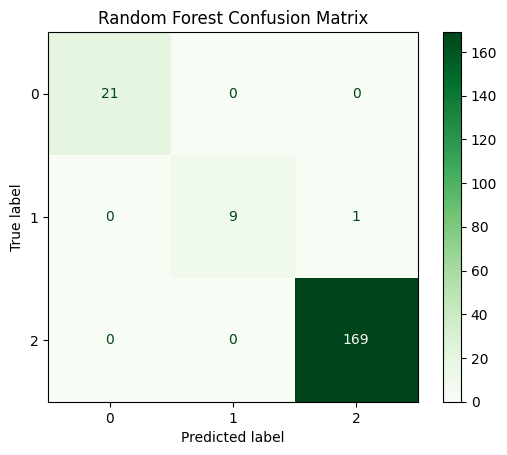

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()